# Developing a Linear Regression Model for Health Insurance Cost Prediction

## Introduction

Prediction of medical costs for a patient is important to enable hospitals to accurately predict revenue and plan necessary procedures that may be required by the patient population. 

The aim of this work:

* Develop a linear regression model for reliable prediction of the health insurance premium of a patient, given some of the patient's personal information.

The dataset to be used was acquired from [Kaggle](https://www.kaggle.com/datasets/mirichoi0218/insurance?resource=download), containing personal and medical data on over 1,300 patients alongside the health insurance premium each patient is required to pay to have their medical costs covered.

#### Data Dictionary

| Column                                 | Description                                                                                                                   |
|----------------------------------------|-------------------------------------------------------------------------------------------------------------------------------|
| age                                    | Age of patient                                                                                                                |
| sex                                    | Gender of patient                                                                                                             |
| bmi                                    | Body mass index [mass (kg) / height^2 (m)]                                                                                    |
| children                               | Number of children                                                                                                            |
| smoker                                 | Smoking status (Yes/No)                                                                                                       |
| region                                 | General US region where patient lives (southeast, southwest, northeast, northwest)                                            |
| charges                                | Health insurance premium (US$)                                                                                                |

## Exploring the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style('whitegrid')

medical_data = pd.read_csv('medical_costs.csv')
medical_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
nulls = medical_data.isnull().sum()
nulls

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [3]:
medical_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [4]:
medical_data.describe(include=["str"])

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


In [5]:
medical_data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
numerical_features = medical_data.select_dtypes(include=[np.number])
categorical_features = medical_data.select_dtypes(include=[str])

## Visualizing Categorical Variables

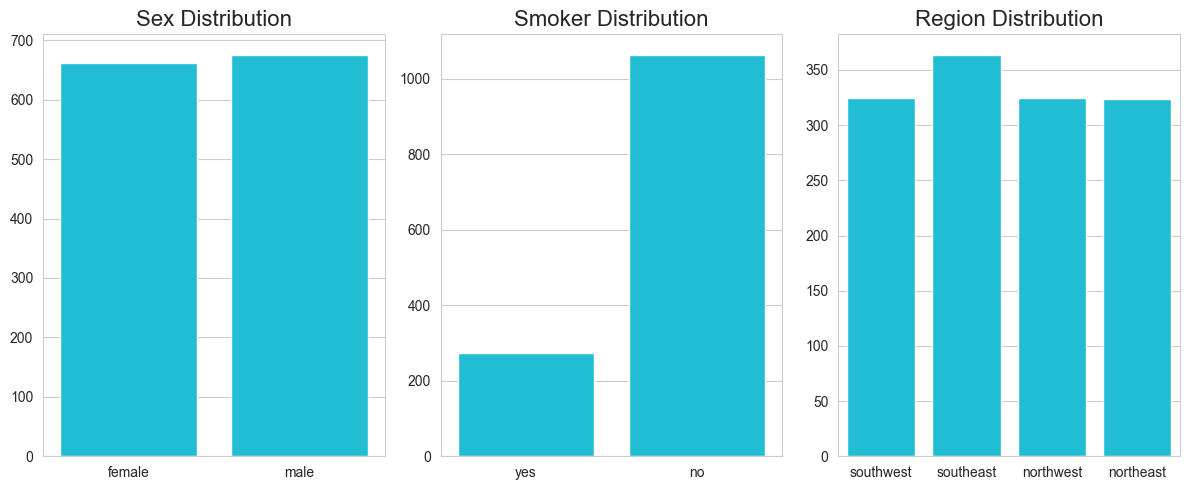

In [7]:
plt.figure(figsize=(12, 5))

for i, feature in enumerate(categorical_features):
  plt.subplot(1, 3, i+1)
  sns.countplot(x=categorical_features[feature], data=medical_data, color="#04d4f0")
  plt.title(f"{feature.title()} Distribution", fontsize=16)
  plt.xlabel("")
  plt.ylabel("")
  
plt.tight_layout()
plt.show()

## Visualizing Numerical Variables

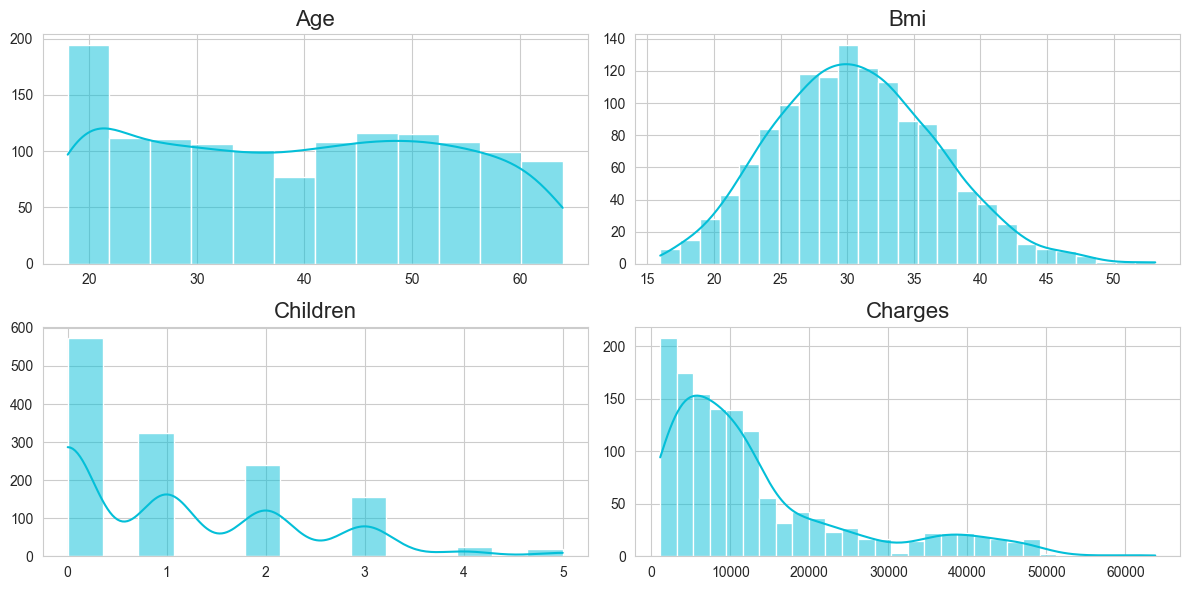

In [8]:
plt.figure(figsize=(12, 6))

for i, feature in enumerate(numerical_features):
  plt.subplot(2, 2, i+1)
  sns.histplot(x=medical_data[feature], data=medical_data, color="#04bfd8", kde=True)
  plt.title(f"{feature.title()}", fontsize=16)
  plt.xlabel("")
  plt.ylabel("")
  
plt.tight_layout()
plt.show()

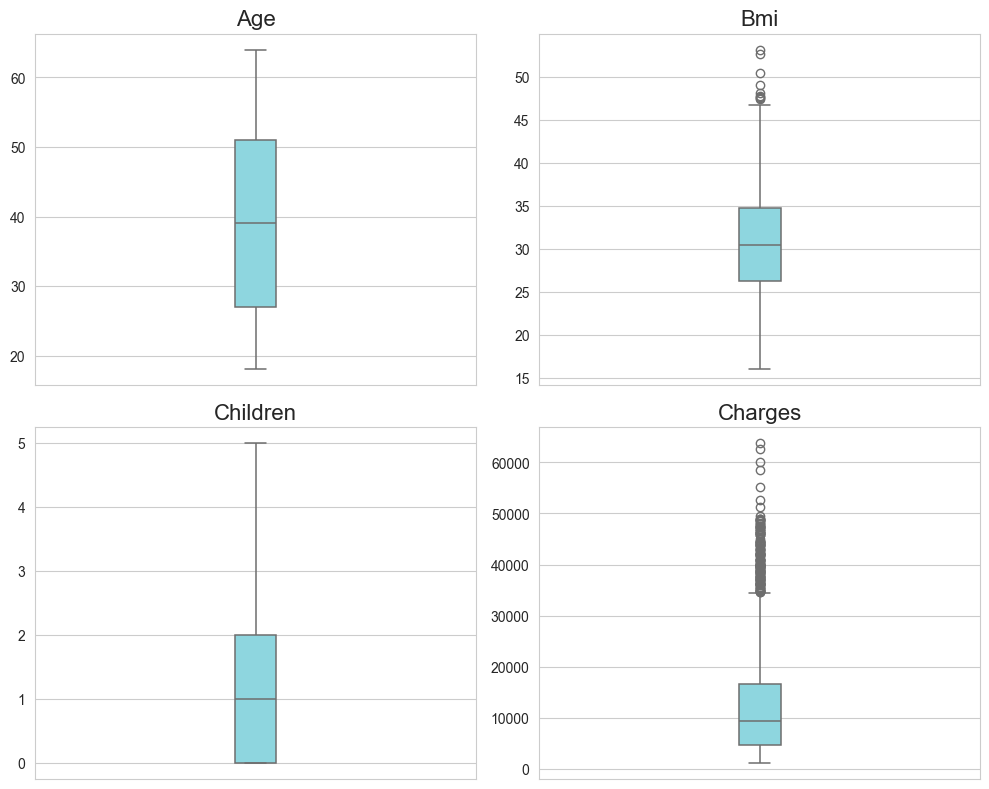

In [9]:
plt.figure(figsize=(10, 8))

for i, feature in enumerate(numerical_features):
  plt.subplot(2, 2, i+1)
  sns.boxplot(y=medical_data[feature], data=medical_data, color="#81e0ec", width=0.1, gap=0.05, linewidth=1.1)
  plt.title(f"{feature.title()}", fontsize=16)
  plt.xlabel("")
  plt.ylabel("")
  
plt.tight_layout()
plt.show()

From the above, we see the target variable `charges` is highly right skewed. It may be appropriate to perform a **log-transform** to approximate a normal distribution. This is important to lessen the influence that extreme values may have on the estimated model coefficients.

### Log Transform

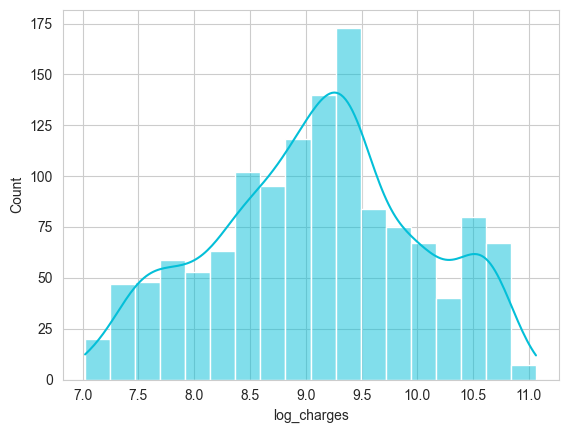

In [10]:
medical_data["log_charges"] = np.log(medical_data["charges"])

sns.histplot(x=medical_data["log_charges"], data=medical_data, color="#04bfd8", kde=True)

plt.show()

The transform has led to a distribution that better approximate a normal distribution, as desired. Moving forward, we will aim to build a model to predict the natural log of the `charges` variable.

## Correlations

To aid in feature selection for modelling, looking into correlations between the predictors as well as with the target variable (`charges`) is an important step. 

For linear regression modelling, we ideally want to avoid **collinearity**. This occurs when predictors used in a model are highly correlated with each other. If this cannot be avoided, principal component analysis can be employed. In scenarios where collinearity is not a problem, we do not need to perform any dimensionality reduction and can instead select relevant features based on how strongly correlated they are to the target variable.

### Numerical Predictors: Pearson's r

To gain an insight into the strength of the linear relationship between the target variable `charge` and the numerical predictors, we can visualize the correlation matrix. This will only capture linear relationships, so will be treated as a starting point.

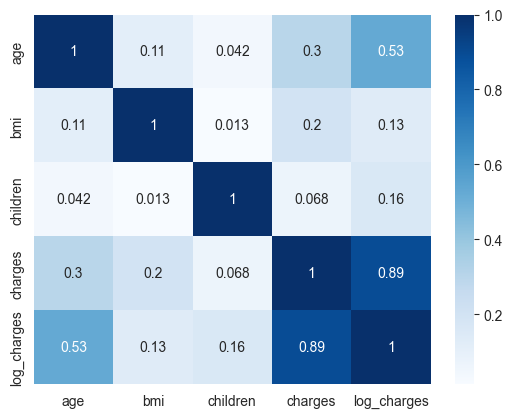

In [11]:
numerical_features = medical_data.select_dtypes(include=[np.number]) # update numerical features to include log_charges column

sns.heatmap(numerical_features.corr(), annot=True, cmap="Blues")
plt.show()

`age` and `bmi` show the strongest evidence of an association with the target variable. We can verify this by visualizing the relationships between the numerical predictors and the target variable.

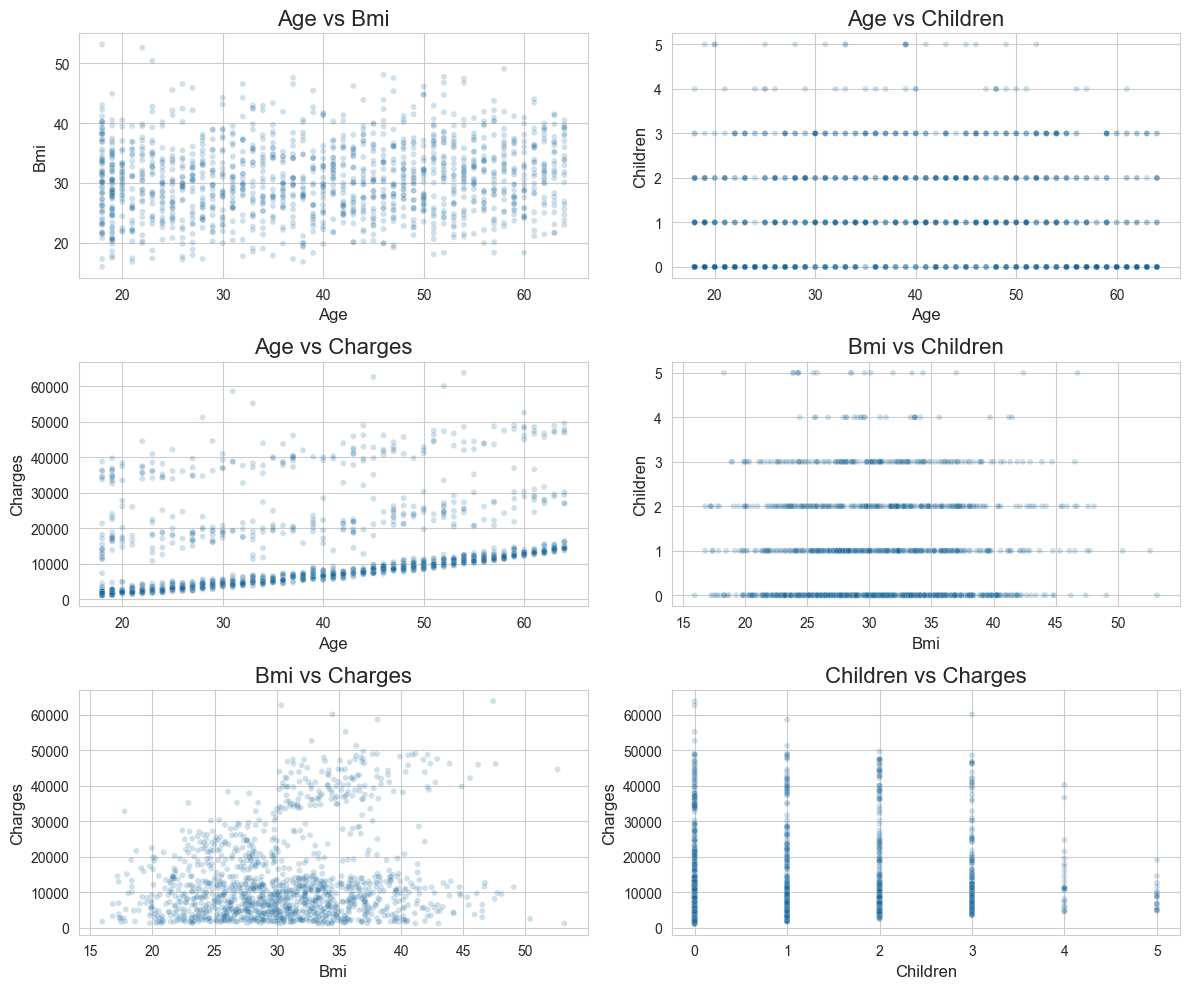

In [12]:
plots = [("age", "bmi"), ("age", "children"), ("age", "charges"), ("bmi", "children"), ("bmi", "charges"), ("children", "charges")]

plt.figure(figsize=(12, 10))

for x, y in plots:
  plt.subplot(3, 2, plots.index((x, y))+1)
  sns.scatterplot(x=numerical_features[x], y=numerical_features[y], size=10, data=medical_data, color="#146499", alpha=0.2, legend=False)
  plt.title(f"{x.title()} vs {y.title()}", fontsize=16)
  plt.xlabel(f"{x.title()}", fontsize=12)
  plt.ylabel(f"{y.title()}", fontsize=12)
  
plt.tight_layout()
plt.show()

This is supported by the scatterplots above. Only the `bmi`-`charges` and `age`-`charges` plots show evidence of a correlation. All other scatterplots show no correlation.

### Categorical Predictors

To investigate correlations between categorical predictors, Cramér’s V will be used. 

To assess whether there are correlations between the target variable (which is numerical) and the categorical predictors, a categorical version of the target variable can be created by creating a binary target variable column: 

1. True where the total charge exceeds the median charge in the `charges` distribution.

2. False where the total charge does not exceed the median charge in the `charges` distribution.

In [13]:
categorical_features_and_charges = categorical_features.copy()
categorical_features_and_charges["charges"] = medical_data["charges"]

# create binary column for target variable
categorical_features_and_charges["exceeds_median_charge"] = categorical_features_and_charges["charges"] > categorical_features_and_charges["charges"].median() 
categorical_features_and_charges.drop(columns=["charges"], inplace=True) # drop numerical column, since only the binary charge column is required

categorical_features_and_charges.head()

,sex,smoker,region,exceeds_median_charge
0,female,yes,southwest,True
1,male,no,southeast,False
2,male,no,southeast,False
3,male,no,northwest,True
4,male,no,northwest,False


### Defining the Cramér’s V Function

To calculate Cramér’s V for two categorical variables, a Chisquare test of association between the two variables must be conducted. The resulting Chisquare test statistic can then be used to find the Cramér’s V value to test for the strength of any association found from the Chisquare test.

Cramér’s V is given by the formula:

$$
V = \sqrt{\frac{\chi^{2}}{n \cdot min(r-1,c-1)}}
$$
where $\chi^{2}$ is the Chisquare test statistic, $n$ is the number of observations in the dataset and $r$, $c$ represent the number of rows and columns in the contingency table respectively. 

V will take a value between 0 and 1:

* $V = 0$ indicates no association between the variables

* $0 < V ≤ 0.1$ indicates a weak association

* $0.1 < V ≤ 0.3$ moderate association

* $0.3 < V ≤ 0.5$ strong association

* $V > 0.5$ very strong association


The function `cramers_v` is defined to do all of these steps, returning a formatted string containing the results of the Chisquare test and corresponding Cramér’s V value.

In [14]:
from scipy.stats import chi2_contingency

def cramers_v(feature1: pd.Series, feature2: pd.Series, df: pd.DataFrame):
  
  """A function which performs a chi-square test of independence and calculates Cramér's V for two categorical features.
  
  The function takes in two pandas Series representing the categorical features and the DataFrame they belong to. It returns a string containing the chi-square statistic, p-value, degrees of freedom, observed/expected frequencies and Cramér's V."""
  
  contingency_table = pd.crosstab(feature1, feature2)
  contingency_array = contingency_table.to_numpy()
  chisq_stat, pval, dof, expected = chi2_contingency(contingency_table)
  V = np.sqrt(chisq_stat / (df.shape[0] * (min(contingency_table.shape) - 1)))
  
  return f"""Chi-square statistic: {chisq_stat}
p-value: {pval}
Degrees of freedom: {dof}

=======================================

Observed frequencies:

{contingency_array}

=======================================

Expected frequencies:
 
{expected}

=======================================

Cramér's V: {V:.4f}"""

### Identifying Suitable Categorical Predictors 

To evaluate the suitability of the categorical variables as predictors in the model, a Chisquare test and Cramér's V for each pair of categorical variable with the binary target variable can be found.

In [15]:
print(cramers_v(categorical_features_and_charges["exceeds_median_charge"], categorical_features_and_charges["sex"], categorical_features_and_charges))

Chi-square statistic: 0.0029898639589552903
p-value: 0.9563936832543802
Degrees of freedom: 1


Observed frequencies:

[[330 339]
 [332 337]]


Expected frequencies:

[[331. 338.]
 [331. 338.]]


Cramér's V: 0.0015


No association between gender and charge. It does not seem necessary to include gender as a predictor in the regression model.

In [16]:
print(cramers_v(categorical_features_and_charges["exceeds_median_charge"], categorical_features_and_charges["smoker"], categorical_features_and_charges))

Chi-square statistic: 342.04970226661544
p-value: 2.2828943016216297e-76
Degrees of freedom: 1


Observed frequencies:

[[669   0]
 [395 274]]


Expected frequencies:

[[532. 137.]
 [532. 137.]]


Cramér's V: 0.5056


The Chisquare p-value obtained is virtually zero - it is **practically certain** that there is an association between smoking status and medical charges. The Cramér’s V value of 0.5056 indicates this association is **very strong**. 

This certainly should be a predictor in the regression model.

In [17]:
print(cramers_v(categorical_features_and_charges["exceeds_median_charge"], categorical_features_and_charges["region"], categorical_features_and_charges))

Chi-square statistic: 4.465988332654999
p-value: 0.21534418797301605
Degrees of freedom: 3


Observed frequencies:

[[146 168 184 171]
 [178 157 180 154]]


Expected frequencies:

[[162.  162.5 182.  162.5]
 [162.  162.5 182.  162.5]]


Cramér's V: 0.0578


Insufficient evidence at the 5% significance level to reject the null hypothesis. We can safely conclude there is no association between region and charge. As a result, we can likely omit the region variable from the regression model.

As it currently stands, the following variables have been identified as good candidates for a regression model due to the correlations observed with the target variable:

* `smoker`
* `age`
* `bmi`

### Checking for Collinearity

It is also important to check if correlations exist between the categorical predictor selected for the model (`smoker`) and the two numerical predictors (`age` and `bmi`). This is key to establishing if collinearity is present.

To do this, categorical versions of the `age` and `bmi` columns must be prepared and passed to the Cramér's V function.

In [18]:
predictors = medical_data[["age", "bmi", "smoker"]]

def age_categorization(age):
  if age < 25:
    return "18-25"
  elif age < 35:
    return "25-35"
  elif age < 45:
    return "35-45"
  elif age < 55:
    return "45-55"
  else:
    return "55-65"

predictors["age_range"] = predictors["age"].apply(age_categorization)

def bmi_categorization(bmi):
  if bmi < 18.5:
    return "Underweight"
  elif bmi < 25:
    return "Normal weight"
  elif bmi < 30:
    return "Overweight"
  elif bmi < 40:
    return "Obese"
  else:
    return "Morbidly obese"
  
predictors["bmi_category"] = predictors["bmi"].apply(bmi_categorization)

predictors.head()

,age,bmi,smoker,age_range,bmi_category
0,19,27.900,yes,18-25,Overweight
1,18,33.770,no,18-25,Obese
2,28,33.000,no,25-35,Obese
3,33,22.705,no,25-35,Normal weight
4,32,28.880,no,25-35,Overweight


#### Smoking vs Age

In [19]:
print(cramers_v(predictors["smoker"], predictors["age_range"], predictors))

Chi-square statistic: 3.3887467527602224
p-value: 0.49499495298410234
Degrees of freedom: 4


Observed frequencies:

[[218 215 199 232 200]
 [ 60  56  61  55  42]]


Expected frequencies:

[[221.07025411 215.50373692 206.75635277 228.22720478 192.44245142]
 [ 56.92974589  55.49626308  53.24364723  58.77279522  49.55754858]]


Cramér's V: 0.0503


There is insufficent evidence at the 5% significance level to reject the null hypothesis. There is no reason to believe a relationship between smoking status and age exists.

#### Smoking vs BMI

In [20]:
print(cramers_v(predictors["smoker"], predictors["bmi_category"], predictors))

Chi-square statistic: 1.4996864992184222
p-value: 0.8266969985769038
Degrees of freedom: 4


Observed frequencies:

[[ 70 175 492 312  15]
 [ 21  50 124  74   5]]


Expected frequencies:

[[ 72.36472347 178.92376682 489.85351271 306.95366218  15.90433483]
 [ 18.63527653  46.07623318 126.14648729  79.04633782   4.09566517]]


Cramér's V: 0.0335


There is insufficent evidence at the 5% significance level to reject the null hypothesis. There is no reason to believe a relationship between smoking status and bmi exists.

#### Age vs BMI

In [21]:
print(cramers_v(predictors["age_range"], predictors["bmi_category"], predictors))

Chi-square statistic: 23.751242762477585
p-value: 0.09508016397124062
Degrees of freedom: 16


Observed frequencies:

[[ 15  55 127  74   7]
 [ 18  55 111  82   5]
 [ 17  42 110  87   4]
 [ 24  47 138  76   2]
 [ 17  26 130  67   2]]


Expected frequencies:

[[ 18.90732436  46.74887892 127.98804185  80.20029895   4.1554559 ]
 [ 18.43124066  45.57174888 124.76532138  78.18086697   4.05082212]
 [ 17.68310912  43.72197309 119.70104634  75.00747384   3.88639761]
 [ 19.51943199  48.26233184 132.13153961  82.79671151   4.28998505]
 [ 16.45889387  40.69506726 111.41405082  69.81464873   3.61733931]]


Cramér's V: 0.0666


Insufficent evidence at the 5% significance level to reject the null hypothesis. The relationship between age and BMI is not statistically significant. 

It is worth noting however that the p-value is somewhat low, indicating there is about a 90.5% chance that a relationship actually does exist. If this is the case, the Cramér's V value would suggest this association is *weak* however.

---


There is no evidence of any correlation amongst the selected features. Collinearity should not be an issue when constructing a linear regression model.

The predictors we can move forward with:

* `bmi`

* `age`

* `smoker`

## Fitting a Multiple Linear Regression Model

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

X = predictors[["age", "bmi", "smoker"]]
y = medical_data["log_charges"]

X = pd.get_dummies(X, columns=["smoker"], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

medical_cost_model = LinearRegression()
medical_cost_model.fit(X_train, y_train)

y_train_pred = medical_cost_model.predict(X_train)
y_test_pred = medical_cost_model.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_mse_original_scale = np.exp(train_mse) # since the model was trained on natural log transformed charges, we need to exponentiate the MSE to get it back to the original scale of charges
test_mse_original_scale = np.exp(test_mse)

R2 = r2_score(y_train, y_train_pred)

intercept = medical_cost_model.intercept_
coefficients = medical_cost_model.coef_

intercept, coefficients, R2, train_mse, test_mse, train_mse_original_scale, test_mse_original_scale

(np.float64(7.0700616881261755),
 array([0.03525471, 0.01083897, 1.547207  ]),
 0.7433336007728251,
 0.21520412786852908,
 0.2176106976833804,
 np.float64(1.240115013165516),
 np.float64(1.2431030305172155))

The fitted multiple linear regression model can be expressed with the following equation:

$$
ln(Y) = 7.070 + 0.035(Age)  + 0.011(BMI) + 1.547(Smoker)
$$

* $R^{2}$ = 0.743

* Training MSE = 0.215

* Testing MSE = 0.218

Since the model was trained on the log-transformed target variable, the MSEs need to be exponentiated to get them back into the scale of the original target variable:

$$
Cost = e^{7.070} \cdot e^{0.035(Age)} \cdot e^{0.011(BMI)} \cdot e^{1.547(Smoker)}
$$

* Training MSE = 1.240

* Testing MSE = 1.243

A coefficient of determination ($R^{2}$) of 0.743 suggests the regression line fits the training data quite strongly. 

The training and testing mean standard errors are relatively small and are very close in magnitude, implying the model is not overfitting the data and is generalizing to unseen data well.

### Interpreting the Model Parameters

Looking at the log-transformed regression model, 

* The intercept does not really have an interpretable meaning since the age and bmi predictors lose their meaning if set to zero - there is no meaning in predicting the log charge of a patient with age and bmi of zero.

* A year increase in `age` is associated with an increase of 0.035 in the log charges variable (holding bmi and smoking status constant).

* A unit increase in `bmi` is associated with an increase of 0.011 in the log charges variable (holding age and smoking status constant).

* A smoker is associated with an increase of 1.547 in the log charges variable.


## Residual Diagnostics

In order to fully evaluate the validity of the fit, the residuals must be assessed.

In [23]:
residuals = y_train - y_train_pred

residuals_mean = np.mean(residuals)
residuals_mean

np.float64(-5.791312926060637e-16)

The mean of the residuals is practically zero, so this does not violate the assumption of linearity.

In [24]:
plot_data = pd.DataFrame({"prediction": y_train_pred, 
                          "true_value": y_train, 
                          "residual": residuals,
                          "smoker": X_train["smoker_yes"],
                          "age": X_train["age"],
                          "bmi": X_train["bmi"]}).reset_index(drop=True)

plot_data.head()

,prediction,true_value,residual,smoker,age,bmi
0,8.172571,7.763433,-0.409138,False,24,23.655
1,8.344535,8.375731,0.031197,False,28,26.510
2,9.298359,9.147544,-0.150815,False,51,39.700
3,10.665310,10.650439,-0.014871,True,47,36.080
4,9.005025,9.085149,0.080124,False,46,28.900


#### Residuals Plot

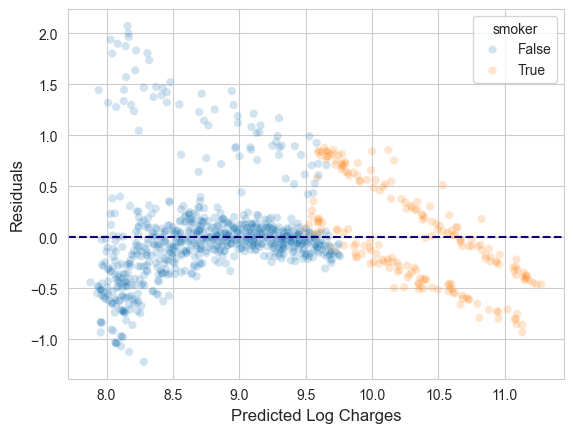

In [25]:
sns.scatterplot(x="prediction", y="residual", data=plot_data, color="#0f8696", hue="smoker", alpha=0.2)
plt.xlabel("Predicted Log Charges", fontsize=12)
plt.ylabel("Residuals", fontsize=12)
plt.axhline(y=0, color="#110074FF", linestyle="--")

plt.show()

Plotting the residuals against predicted `log_charges` we see an even band centered around 0 for a large cluster of the data, which is aligned with the assumptions of a linear fit. 

However, there are clear signs of additional trends, namely there appears to be linear trends on the right-side of the plot. We can also see there is clear segmentation between observations that are positive for smoking status and those that are negative, with smokers consistently being predicted greater `log_charges` and showcasing a linear trend in the residual plot where this is not present for the non-smokers.

Additionally, for some reason, there are groupings of non-smokers where the model either over-estimates or under-estimates their medical costs (seen by the cluster of datapoints in the bottom left of the plot and the cluster of points in the top left respectively). It is likely that additional factors are at play that the model fails to caputure.

In [26]:
plot_data[plot_data["residual"] > 1].sample(10)

,prediction,true_value,residual,smoker,age,bmi
359,8.071871,9.348591,1.276720,False,18,33.880
458,8.423768,9.887019,1.463252,False,28,33.820
969,8.206551,9.442236,1.235686,False,24,26.790
958,9.107728,10.318396,1.210668,False,50,25.365
742,9.151515,10.180826,1.029311,False,48,35.910
914,9.129351,10.152555,1.023204,False,50,27.360
596,7.940719,9.382952,1.442233,False,18,21.780
221,8.766748,9.863431,1.096683,False,37,36.190
835,8.167747,10.129896,1.962149,False,24,23.210
343,8.242942,9.286925,1.043984,False,23,33.400


Taking a glance at the datapoints with residuals exceeding +1, we confirm they are non-smokers, but it is difficult to spot a trend between the age and bmi predictors that explains why these patient's costs are under-estimated. We likely need to work on the model predictors to correct this.

In [27]:
plot_data[plot_data["residual"] < -0.95].sample(10)

,prediction,true_value,residual,smoker,age,bmi
846,8.069486,7.035620,-1.033866,False,18,33.66
116,8.109510,7.140011,-0.969499,False,19,34.10
211,8.065909,7.035216,-1.030693,False,18,33.33
229,8.077832,7.036562,-1.041271,False,18,34.43
583,8.074255,7.036158,-1.038097,False,18,34.10
985,8.112762,7.140341,-0.972420,False,19,34.40
114,8.123601,7.141442,-0.982158,False,19,35.40
658,8.108832,7.040050,-1.068781,False,18,37.29
512,8.280521,7.059156,-1.221365,False,18,53.13
139,8.170831,7.046992,-1.123839,False,18,43.01


However, when we glance at some datapoints with residuals less than -0.95, we find these are very young patients (aged 18/19) at the lower limit of the age range. It seems as though the model **over-estimates** the medical costs for young patients.

## Visualizing Predicted Values vs. True Values

Before moving on to refining the model, it would be beneficial to visualize the trend between model predictions and the true values.

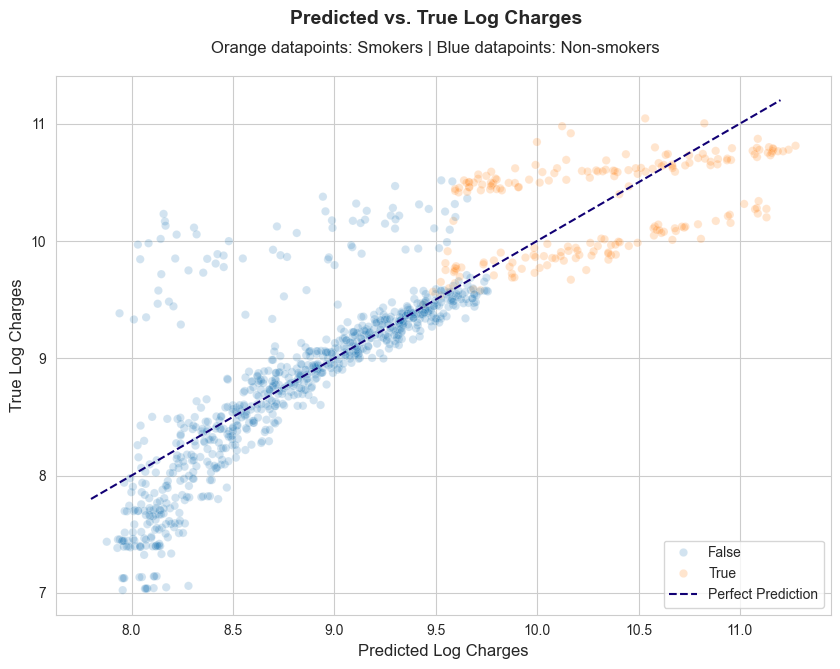

In [28]:
plt.figure(figsize=(10, 7))

sns.scatterplot(data=plot_data, x="prediction", y="true_value", color="#0f8696", hue="smoker", alpha=0.2)
plt.plot([7.8, 11.2], [7.8, 11.2], color="#110074FF", linestyle="--", label="Perfect Prediction") # add line of perfect prediction for reference
plt.xlabel("Predicted Log Charges", fontsize=12)
plt.ylabel("True Log Charges", fontsize=12)
plt.text(9.5, 11.85, "Predicted vs. True Log Charges", fontsize=14, ha="center", weight="bold")
plt.text(9.5, 11.6, "Orange datapoints: Smokers | Blue datapoints: Non-smokers", fontsize=12, ha="center")

plt.legend(loc="lower right")
plt.show()

### Next Steps

This highlights the failure of the model to reliably predict the medical charges of smokers. There are two distinct groupings amongst the smokers, one where the model typically under-estimates costs and those where the model typically over-estimates cost.

To address this, we can build a separate model for smokers since it seems as though the way in which medical costs are calculated for smokers is fundamentally different than non-smokers.

On a separate note, even amongst non-smokers, we have identified clusters of patients where the model accuracy is poor. We can potentially trial the inclusion of **interaction terms** and/or **polynomial terms** into the model to see if this leads to an improvement.

## Segmenting the Data by Smoking Status

In [29]:
smokers = medical_data[medical_data["smoker"] == "yes"]
non_smokers = medical_data[medical_data["smoker"] == "no"]

smokers.head()

,age,sex,bmi,children,smoker,region,charges,log_charges
0,19,female,27.90,0,yes,southwest,16884.9240,9.734176
11,62,female,26.29,0,yes,southeast,27808.7251,10.233105
14,27,male,42.13,0,yes,southeast,39611.7577,10.586881
19,30,male,35.30,0,yes,southwest,36837.4670,10.514271
23,34,female,31.92,1,yes,northeast,37701.8768,10.537465


In [30]:
non_smokers.head()

,age,sex,bmi,children,smoker,region,charges,log_charges
1,18,male,33.770,1,no,southeast,1725.55230,7.453302
2,28,male,33.000,3,no,southeast,4449.46200,8.400538
3,33,male,22.705,0,no,northwest,21984.47061,9.998092
4,32,male,28.880,0,no,northwest,3866.85520,8.260197
5,31,female,25.740,0,no,southeast,3756.62160,8.231275


### Building a Smoker Model

In [31]:
smoker_predictors = smokers[["age", "bmi"]]
y = smokers["log_charges"]

X_train_smokers, X_test_smokers, y_train_smokers, y_test_smokers = train_test_split(smoker_predictors, y, test_size=0.25, random_state=42)

medical_cost_model_smokers = LinearRegression()
medical_cost_model_smokers.fit(X_train_smokers, y_train_smokers)

y_train_smokers_pred = medical_cost_model_smokers.predict(X_train_smokers)
y_test_smokers_pred = medical_cost_model_smokers.predict(X_test_smokers)

train_mse_smokers = mean_squared_error(y_train_smokers, y_train_smokers_pred)
test_mse_smokers = mean_squared_error(y_test_smokers, y_test_smokers_pred)

train_mse_smokers_original_scale = np.exp(train_mse_smokers)
test_mse_smokers_original_scale = np.exp(test_mse_smokers)

R2_smokers = r2_score(y_train_smokers, y_train_smokers_pred)

intercept_smokers = medical_cost_model_smokers.intercept_
coefficients_smokers = medical_cost_model_smokers.coef_

intercept_smokers, coefficients_smokers, R2_smokers, train_mse_smokers, test_mse_smokers, train_mse_smokers_original_scale, test_mse_smokers_original_scale

(np.float64(8.443703877578008),
 array([0.00889204, 0.0492047 ]),
 0.7661650418251627,
 0.03385442188133927,
 0.045239831294230544,
 np.float64(1.034434004809913),
 np.float64(1.0462787602098294))

The fitted multiple linear regression model for smokers can be expressed with the following equation:

$$
ln(Y) = 8.444 + 0.009(Age)  + 0.049(BMI)
$$

* $R^{2}$ = 0.766

* Training MSE = 0.034

* Testing MSE = 0.045

Since the model was trained on the log-transformed target variable, the MSEs need to be exponentiated to get them back into the scale of the original target variable:

$$
Cost = e^{8.444} \cdot e^{0.009(Age)} \cdot e^{0.049(BMI)}
$$

* Training MSE = 1.034

* Testing MSE = 1.046

A coefficient of determination ($R^{2}$) of 0.766 suggests the regression line fits the training data quite strongly. This is an improvement over the model fit which used all of the data.

The training and testing mean standard errors are noticeably smaller than the first iteration of the model and remain close in magnitude, implying the model is not overfitting the data, provides more reliable predictions and is generalizing to unseen data well.

### Residual Diagnostics

As before, it is necessary to analyse the residuals of the model to verify that a linear relationship is a suitable fit.

In [32]:
smoker_residuals = y_train_smokers - y_train_smokers_pred

smoker_residuals_mean = np.mean(smoker_residuals)
smoker_residuals_mean

np.float64(2.599546594244269e-17)

The mean of the residuals is practically zero, which does not violate the assumption for a linear model.

In [33]:
smoker_plot_data = pd.DataFrame({"prediction": y_train_smokers_pred, 
                          "true_value": y_train_smokers, 
                          "residual": smoker_residuals,
                          "age": X_train_smokers["age"],
                          "bmi": X_train_smokers["bmi"]}).reset_index(drop=True)

smoker_plot_data.head()

,prediction,true_value,residual,age,bmi
0,10.059447,10.467310,0.407863,24,28.5
1,9.875844,9.831361,-0.044483,36,22.6
2,9.993759,9.862663,-0.131096,31,25.9
3,11.008080,10.767704,-0.240376,51,42.9
4,10.675914,10.777456,0.101542,64,33.8


### Residuals Plot

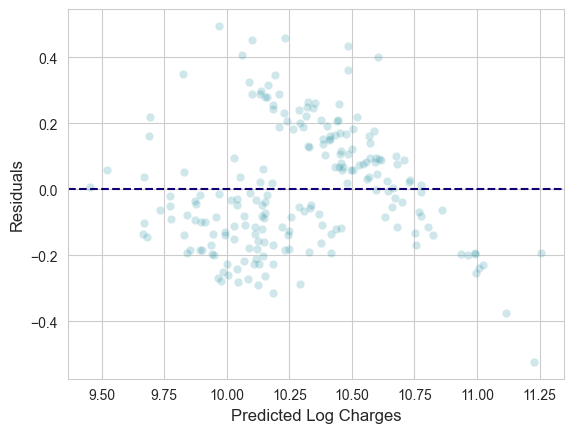

In [34]:
sns.scatterplot(x="prediction", y="residual", data=smoker_plot_data, color="#0f8696", alpha=0.2)
plt.xlabel("Predicted Log Charges", fontsize=12)
plt.ylabel("Residuals", fontsize=12)
plt.axhline(y=0, color="#110074FF", linestyle="--")

plt.show()

The residuals plot is improved significantly compared to the first iteration of the model. There is still evidence of a non-random trend however. 

We can move forward with this model and trial interaction terms and/or polynomial terms to see if we can improve the accuracy and further minimize errors.

---

Before doing this, we can first summarize the accuracy of the smoker model as it stands:

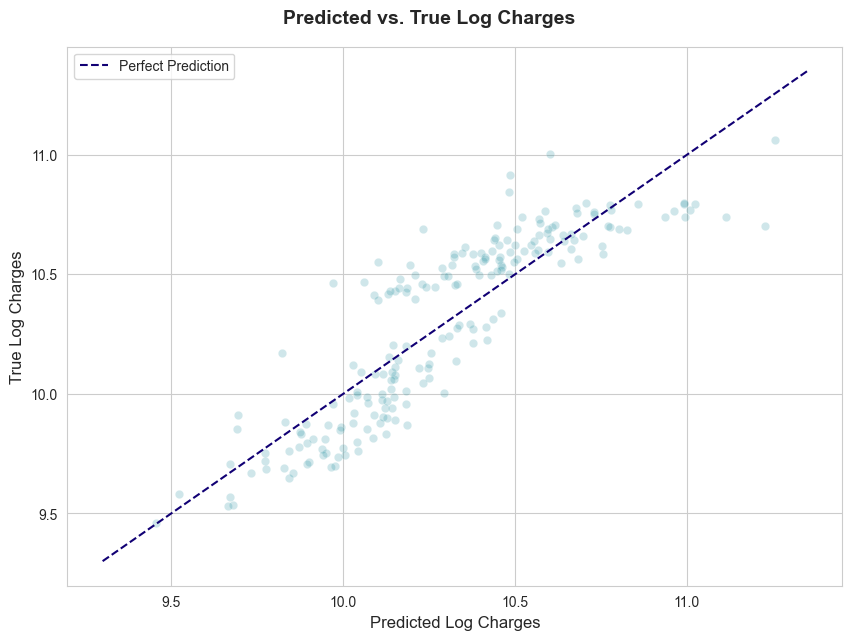

In [35]:
plt.figure(figsize=(10, 7))

sns.scatterplot(data=smoker_plot_data, x="prediction", y="true_value", color="#0f8696", alpha=0.2)
plt.plot([9.3, 11.35], [9.3, 11.35], color="#110074FF", linestyle="--", label="Perfect Prediction") # add line of perfect prediction for reference
plt.xlabel("Predicted Log Charges", fontsize=12)
plt.ylabel("True Log Charges", fontsize=12)
plt.text(10.25, 11.55, "Predicted vs. True Log Charges", fontsize=14, ha="center", weight="bold")

plt.legend(loc="upper left")
plt.show()

#### Adding an Interaction Term

In [36]:
smokers["age_bmi"] = smokers["age"] * smokers["bmi"]

smoker_predictors = smokers[["age", "bmi", "age_bmi"]]
y = smokers["log_charges"]

X_train_smokers, X_test_smokers, y_train_smokers, y_test_smokers = train_test_split(smoker_predictors, y, test_size=0.25, random_state=42)

medical_cost_model_smokers_with_interaction = LinearRegression()
medical_cost_model_smokers_with_interaction.fit(X_train_smokers, y_train_smokers)

y_train_smokers_pred = medical_cost_model_smokers_with_interaction.predict(X_train_smokers)
y_test_smokers_pred = medical_cost_model_smokers_with_interaction.predict(X_test_smokers)

train_mse_smokers = mean_squared_error(y_train_smokers, y_train_smokers_pred)
test_mse_smokers = mean_squared_error(y_test_smokers, y_test_smokers_pred)

train_mse_smokers_original_scale = np.exp(train_mse_smokers)
test_mse_smokers_original_scale = np.exp(test_mse_smokers)

R2_smokers = r2_score(y_train_smokers, y_train_smokers_pred)

intercept_smokers = medical_cost_model_smokers_with_interaction.intercept_
coefficients_smokers = medical_cost_model_smokers_with_interaction.coef_

intercept_smokers, coefficients_smokers, R2_smokers, train_mse_smokers, test_mse_smokers, train_mse_smokers_original_scale, test_mse_smokers_original_scale

(np.float64(8.202008746588994),
 array([ 0.01532685,  0.0571656 , -0.00021076]),
 0.7681869619732975,
 0.03356169004072988,
 0.04479064081616818,
 np.float64(1.034131237356695),
 np.float64(1.0458088872924651))

We find the inclusion of an interaction term between age and bmi has a negligible effect on the model performance. As a result, the interaction term will not be used.

#### Adding Polynomial Terms

In [37]:
smokers["age**2"] = smokers["age"] ** 2
smokers["bmi**2"] = smokers["bmi"] ** 2

smoker_predictors = smokers[["age", "bmi", "bmi**2", "age**2"]]
y = smokers["log_charges"]

X_train_smokers, X_test_smokers, y_train_smokers, y_test_smokers = train_test_split(smoker_predictors, y, test_size=0.25, random_state=42)

medical_cost_model_smokers_with_poly = LinearRegression()
medical_cost_model_smokers_with_poly.fit(X_train_smokers, y_train_smokers)

y_train_smokers_pred = medical_cost_model_smokers_with_poly.predict(X_train_smokers)
y_test_smokers_pred = medical_cost_model_smokers_with_poly.predict(X_test_smokers)

train_mse_smokers = mean_squared_error(y_train_smokers, y_train_smokers_pred)
test_mse_smokers = mean_squared_error(y_test_smokers, y_test_smokers_pred)

train_mse_smokers_original_scale = np.exp(train_mse_smokers)
test_mse_smokers_original_scale = np.exp(test_mse_smokers)

R2_smokers = r2_score(y_train_smokers, y_train_smokers_pred)

intercept_smokers = medical_cost_model_smokers_with_poly.intercept_
coefficients_smokers = medical_cost_model_smokers_with_poly.coef_

intercept_smokers, coefficients_smokers, R2_smokers, train_mse_smokers, test_mse_smokers, train_mse_smokers_original_scale, test_mse_smokers_original_scale

(np.float64(7.1953900003728535),
 array([ 1.14786233e-02,  1.27965863e-01, -1.22995767e-03, -3.78906181e-05]),
 0.7957355246305792,
 0.02957323309783432,
 0.04644965482947228,
 np.float64(1.0300148638892277),
 np.float64(1.0475453388922162))

Trials with different combinations of quadratic terms ($age^{2}$ and $bmi^{2}$) does seem to improve the fit to the training data somewhat (with $R^{2}$ ~ 0.795), however, there is barely any improvement in the predictive power of the model since the change to the testing MSE is negligible. 

When attempting to incorporate the interaction term alongside the quadratic terms, no significant improvements are made here either.

As a result, it is not deemed appropriate to add more complicated predictors to the model since we are not improving the predictive power, whilst making the model harder to interpret.

## Building a Non-smoker Model

To conclude this work, it is necessary to re-build the model for non-smoking patients and attempt to fine-tune with the approaches trialled for the smoker model.

The same procedure as performed for the smoker model is performed below:

In [38]:
non_smoker_predictors = non_smokers[["age", "bmi"]]
y = non_smokers["log_charges"]

X_train_non_smokers, X_test_non_smokers, y_train_non_smokers, y_test_non_smokers = train_test_split(non_smoker_predictors, y, test_size=0.25, random_state=42)

medical_cost_model_non_smokers = LinearRegression()
medical_cost_model_non_smokers.fit(X_train_non_smokers, y_train_non_smokers)

y_train_non_smokers_pred = medical_cost_model_non_smokers.predict(X_train_non_smokers)
y_test_non_smokers_pred = medical_cost_model_non_smokers.predict(X_test_non_smokers)

train_mse_non_smokers = mean_squared_error(y_train_non_smokers, y_train_non_smokers_pred)
test_mse_non_smokers = mean_squared_error(y_test_non_smokers, y_test_non_smokers_pred)

train_mse_non_smokers_original_scale = np.exp(train_mse_non_smokers)
test_mse_non_smokers_original_scale = np.exp(test_mse_non_smokers)

R2_non_smokers = r2_score(y_train_non_smokers, y_train_non_smokers_pred)

intercept_non_smokers = medical_cost_model_non_smokers.intercept_
coefficients_non_smokers = medical_cost_model_non_smokers.coef_

intercept_non_smokers, coefficients_non_smokers, R2_non_smokers, train_mse_non_smokers, test_mse_non_smokers, train_mse_non_smokers_original_scale, test_mse_non_smokers_original_scale

(np.float64(7.1282123164474624),
 array([0.0417673 , 0.00057886]),
 0.6240935010834165,
 0.20758221255271395,
 0.19229140733018685,
 np.float64(1.2306988915786177),
 np.float64(1.2120236580867723))

$$
ln(Y) = 7.128 + 0.042(Age) + 0.000579(bmi)
$$

Converted back into the original scale:

$$
Cost = e^{7.128} \cdot e^{0.042(Age)} \cdot e^{0.000579(bmi)}
$$

In [39]:
non_smoker_residuals = y_train_non_smokers - y_train_non_smokers_pred

non_smoker_residuals_mean = np.mean(non_smoker_residuals)
non_smoker_residuals_mean

np.float64(-9.382636689313354e-16)

The mean of the residuals does not violate the assumptions of a linear model.

In [40]:
non_smoker_plot_data = pd.DataFrame({"prediction": y_train_non_smokers_pred, 
                          "true_value": y_train_non_smokers, 
                          "residual": non_smoker_residuals,
                          "age": X_train_non_smokers["age"],
                          "bmi": X_train_non_smokers["bmi"]}).reset_index(drop=True)

non_smoker_plot_data.head()

,prediction,true_value,residual,age,bmi
0,9.279572,9.291748,0.012177,51,36.670
1,8.531112,9.334919,0.803808,33,42.460
2,8.647398,8.569372,-0.078026,36,26.885
3,7.902183,7.397452,-0.504731,18,38.280
4,8.520605,8.339285,-0.181320,33,24.310


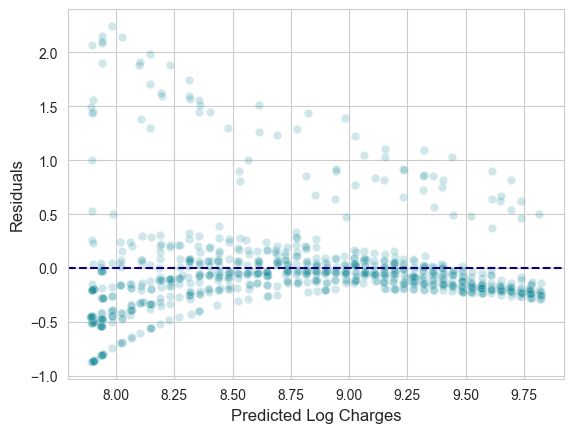

In [41]:
sns.scatterplot(x="prediction", y="residual", data=non_smoker_plot_data, color="#0f8696", alpha=0.2)
plt.xlabel("Predicted Log Charges", fontsize=12)
plt.ylabel("Residuals", fontsize=12)
plt.axhline(y=0, color="#110074FF", linestyle="--")

plt.show()

However, there are certainly signs of a non-linear relationship in the residuals plot. A linear relationship will not capture this.

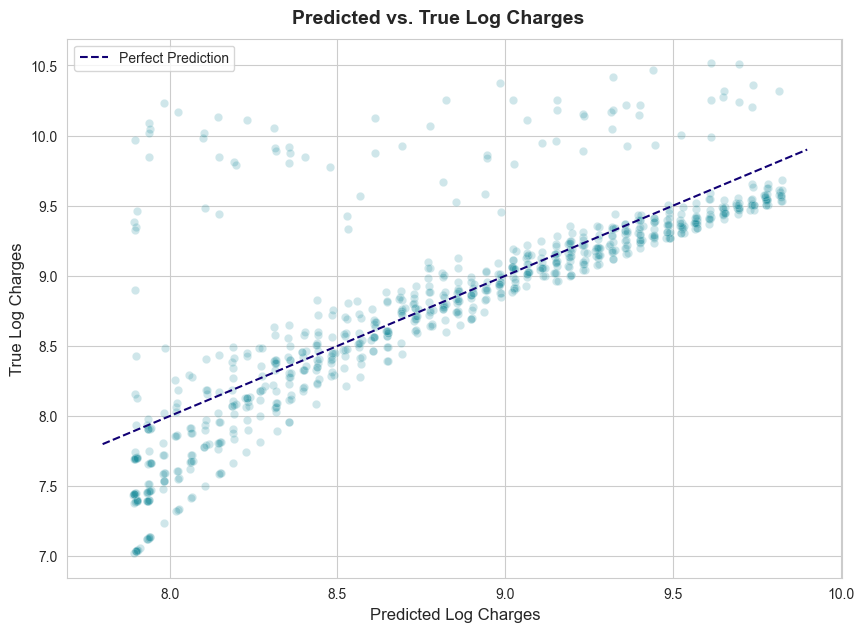

In [42]:
plt.figure(figsize=(10, 7))

sns.scatterplot(data=non_smoker_plot_data, x="prediction", y="true_value", color="#0f8696", alpha=0.2)
plt.plot([7.8, 9.9], [7.8, 9.9], color="#110074FF", linestyle="--", label="Perfect Prediction") # add line of perfect prediction for reference
plt.xlabel("Predicted Log Charges", fontsize=12)
plt.ylabel("True Log Charges", fontsize=12)
plt.text(8.8, 10.8, "Predicted vs. True Log Charges", fontsize=14, ha="center", weight="bold")

plt.legend(loc="upper left")
plt.show()

### Trialling More Predictors

In [43]:
non_smokers["age**2"] = non_smokers["age"] ** 2
non_smokers["log_age"] = np.log(non_smokers["age"])
non_smokers["bmi**2"] = non_smokers["bmi"] ** 2
non_smokers["log_bmi"] = np.log(non_smokers["bmi"])
non_smokers["age_bmi"] = non_smokers["age"] * non_smokers["bmi"]

non_smoker_predictors = non_smokers[["age", "bmi", "log_age", "log_bmi", "age_bmi"]]
y = non_smokers["log_charges"]

X_train_non_smokers, X_test_non_smokers, y_train_non_smokers, y_test_non_smokers = train_test_split(non_smoker_predictors, y, test_size=0.25, random_state=42)

medical_cost_model_non_smokers_complex = LinearRegression()
medical_cost_model_non_smokers_complex.fit(X_train_non_smokers, y_train_non_smokers)

y_train_non_smokers_pred = medical_cost_model_non_smokers_complex.predict(X_train_non_smokers)
y_test_non_smokers_pred = medical_cost_model_non_smokers_complex.predict(X_test_non_smokers)

train_mse_non_smokers = mean_squared_error(y_train_non_smokers, y_train_non_smokers_pred)
test_mse_non_smokers = mean_squared_error(y_test_non_smokers, y_test_non_smokers_pred)

train_mse_non_smokers_original_scale = np.exp(train_mse_non_smokers)
test_mse_non_smokers_original_scale = np.exp(test_mse_non_smokers)

R2_non_smokers = r2_score(y_train_non_smokers, y_train_non_smokers_pred)

intercept_non_smokers = medical_cost_model_non_smokers_complex.intercept_
coefficients_non_smokers = medical_cost_model_non_smokers_complex.coef_

intercept_non_smokers, coefficients_non_smokers, R2_non_smokers, train_mse_non_smokers, test_mse_non_smokers, train_mse_non_smokers_original_scale, test_mse_non_smokers_original_scale

(np.float64(0.7357797085578834),
 array([-5.36128545e-04, -4.39293251e-02,  1.41449567e+00,  1.23422781e+00,
         1.05598756e-04]),
 0.6415560547327079,
 0.19793908179070824,
 0.17984925546508485,
 np.float64(1.218888139077173),
 np.float64(1.197036902749263))

In [44]:
non_smoker_residuals = y_train_non_smokers - y_train_non_smokers_pred

non_smoker_plot_data = pd.DataFrame({"prediction": y_train_non_smokers_pred, 
                          "true_value": y_train_non_smokers, 
                          "residual": non_smoker_residuals,
                          "age": X_train_non_smokers["age"],
                          "bmi": X_train_non_smokers["bmi"]}).reset_index(drop=True)

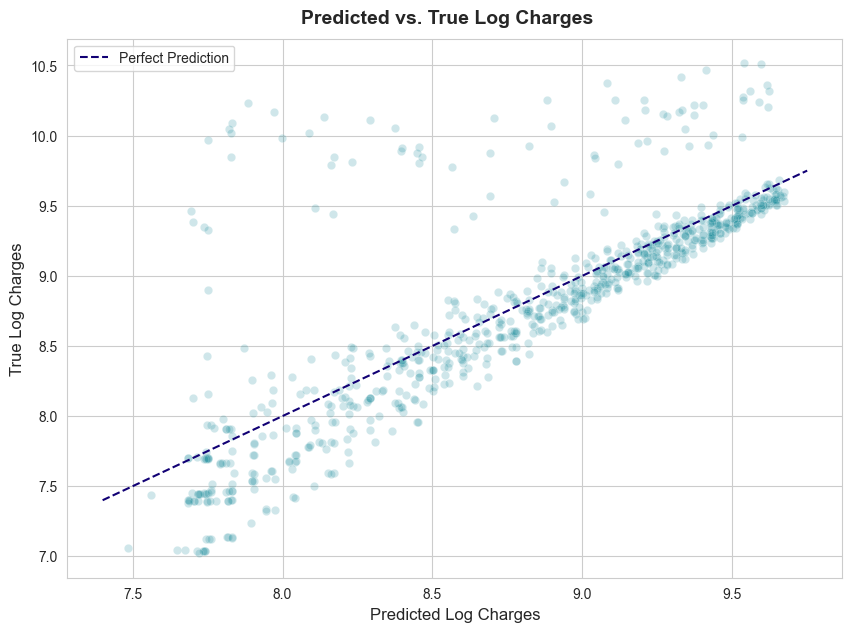

In [45]:
plt.figure(figsize=(10, 7))

sns.scatterplot(data=non_smoker_plot_data, x="prediction", y="true_value", color="#0f8696", alpha=0.2)
plt.plot([7.4, 9.75], [7.4, 9.75], color="#110074FF", linestyle="--", label="Perfect Prediction") # add line of perfect prediction for reference
plt.xlabel("Predicted Log Charges", fontsize=12)
plt.ylabel("True Log Charges", fontsize=12)
plt.text(8.55, 10.8, "Predicted vs. True Log Charges", fontsize=14, ha="center", weight="bold")

plt.legend(loc="upper left")
plt.show()

After messing around with a range of more complicated predictors (quadratic, log and interaction), we do not see any significant improvement. We have managed to improve the fit and **slightly** lower the testing MSE with these extra predictors:

* $R^{2}$ = 0.642 (up from 0.624)

* Training MSE = 1.219 (down from 1.231)

* Testing MSE = 1.197 (down from 1.212)

These improvements are marginal. If we do not care so much about the interpretability of the coefficients, we could move forward with this more complicated model. Mathematically, the model is represented as:

$$
ln(Y) = 0.736 - 0.000536(Age) - 0.0439(BMI)  + 1.414 \cdot ln(Age) + 1.234 \cdot ln(BMI) + 0.000106(Age \cdot BMI)
$$

## Conclusions

Two multiple linear regression models have been developed for the prediction of health insurance premiums of patients in the United States. 

It was determined appropriate to segment the model into two, one for patients who smoke, and another for non-smoking patients:

#### Smoker Model

Model: `medical_cost_model_smokers`

$$
Cost = e^{8.444} \cdot e^{0.009(Age)} \cdot e^{0.049(BMI)}
$$

* $R^{2}$ = 0.766

* Training MSE = 1.034

* Testing MSE = 1.046

The coefficient of determination metric implies a relatively strong fit to the training data. Additionally, the close proximity of the training and testing mean standard errors suggests the model is generalizing well to unseen data - good predictive ability.

---

#### Non-Smoker Model

Model: `medical_cost_model_non_smokers`

$$
Cost = e^{7.128} \cdot e^{0.042(Age)} \cdot e^{0.000579(bmi)}
$$

* $R^{2}$ = 0.624

* Training MSE = 1.231

* Testing MSE = 1.212

The coefficient of determination metric implies an adequate fit to the training data. Additionally, the close proximity of the training and testing mean standard errors suggests the model is generalizing well to unseen data - good predictive ability. 

It is interesting to note that the non-smoker model is typically less reliable than the smoker model, with a slightly poorer fit and worse error metrics. It was found that there were a number of observations in the non-smoker dataset that were being consistently under or over-estimated, showing evidence of non-linear trends. It was noted that young people (particularly those aged 18 and 19) often had their medical charges **overestimated**, which is a short-coming of this model.

Experimentation with more complicated predictors for this model yielded a slight improvement, albeit at the cost of the simplicity of the model:

Model: `medical_cost_model_non_smokers_complex`

$$
ln(Cost) = 0.736 - 0.000536(Age) - 0.0439(BMI)  + 1.414 \cdot ln(Age) + 1.234 \cdot ln(BMI) + 0.000106(Age \cdot BMI)
$$

or 

$$
Cost = \frac{e^{0.736} \cdot e^{0.000106(Age \cdot BMI)} \cdot Age^{1.414} \cdot BMI^{1.234} }{e^{0.000536(Age)} \cdot e^{0.0439(BMI)}}
$$

* $R^{2}$ = 0.642 (up from 0.624)

* Training MSE = 1.219 (down from 1.231)

* Testing MSE = 1.197 (down from 1.212)

Ultimately, to fully capture the non-linear trends in the dataset, it seems likely that models outside of the realm of linear regression would be a better fit. Alternatively, additional features may be necessary to fully capture all trends in the dataset (for example, the patient's blood pressure, cholesterol, disability status *etc.*). 